# 04: Attendance Prediction Model
Linear regression, not a random forest, deliberately. This mirrors how MLB team analytics groups have actually approached this problem: with limited/volatile season-to-season data, interpretability matters more than squeezing out extra accuracy. A model that says "each promo night adds ~X fans, holding everything else constant" is something you can explain to a front office; a random forest's feature importances are not.

**Train:** 2022-2025 (`mets_master.csv`). **Test / backtest:** completed 2026 games (`mets_2026_master.csv`), true unseen data the model has never touched.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

train = pd.read_csv("../data/mets_master.csv")
test = pd.read_csv("../data/mets_2026_master.csv")

train = train.dropna(subset=["attendance"]).reset_index(drop=True)
test = test.dropna(subset=["attendance"]).reset_index(drop=True)
print(f"Train (2022-2025): {len(train)} games")
print(f"Test (2026 completed): {len(test)} games")

# The one fixed reference point for every R² in this notebook: the 2022-2025 historical
# mean, confirmed as the best of four candidate naive baselines later in this notebook.
# Standard sklearn R² instead compares against the TEST set's own mean, which quietly
# assumes you already know the answer, not something you'd have before a season starts.
historical_mean = train["attendance"].mean()
print(f"Historical mean (2022-2025), used as the R² baseline throughout: {historical_mean:,.0f}")

def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_res_baseline = np.sum((y_true - historical_mean) ** 2)
    return {
        "r2": 1 - ss_res / ss_res_baseline,
        "mae": np.mean(np.abs(y_true - y_pred)),
        "rmse": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "mape": np.mean(np.abs(y_true - y_pred) / y_true) * 100,
    }

Train (2022-2025): 311 games
Test (2026 completed): 69 games
Historical mean (2022-2025), used as the R² baseline throughout: 33,876


## Feature Selection
Numeric features go in directly. `opponent` is one-hot encoded to capture the marquee-draw effect found in EDA. `starter_era_diff` is dropped, it's a perfect linear combination of `mets_starter_era` and `opp_starter_era` (multicollinear), so including all three would make coefficients unstable/unreadable.

Also dropped for the same reason: `opp_games_back` (redundant with `opp_win_pct`, same underlying signal) and `opp_streak_num` (correlates -0.85 with `mets_streak_num`).

`mets_games_back` is the one exception: it correlates with `mets_win_pct` (-0.57), the original reason it was excluded, but an ablation test showed it substantially improves the tree-based models (GBM R²=0.147 -> 0.357, MAPE 9.65% -> 8.01% on the 2026 backtest), especially during a sustained losing stretch. "20 games out of first place" captures "meaningfully out of contention" in a way `mets_win_pct` alone doesn't scale to, a .448 win pct doesn't sound catastrophic, but 20 games back does. We tried a trailing last-10-games win pct first as a fix for the same problem, it didn't help (the team's recent form was in line with its season average, not unusually bad, so there was no short-term dip for it to flag), which is what pointed at games_back instead. Kept in despite reintroducing some win_pct correlation, on the linear model specifically this adds to the coefficient instability already flagged below, another reason to read those coefficients for sign/ranking, not exact magnitude.

Rows with no starter ERA yet (pitcher's first start of the season) are dropped rather than imputed, to keep the ERA coefficient honest.

In [2]:
NUMERIC_FEATURES = [
    "season", "month", "dayofweek", "is_weekend", "avg_temp_f", "avg_precip_mm",
    "is_promo", "is_bobblehead", "n_promotions",
    "is_national", "is_premium_national",
    "mets_win_pct", "opp_win_pct",
    "mets_streak_num", "mets_games_back",
    "mets_starter_era", "opp_starter_era",
    "is_day_game", "is_game2",
]
CATEGORICAL_FEATURES = ["opponent"]
TARGET = "attendance"

model_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]

n_before = len(train)
train_model = train[model_cols].dropna()
print(f"Train: dropped {n_before - len(train_model)} rows with missing features ({len(train_model)} remain)")

n_before = len(test)
test_model = test[model_cols].dropna()
print(f"Test: dropped {n_before - len(test_model)} rows with missing features ({len(test_model)} remain)")

Train: dropped 30 rows with missing features (281 remain)
Test: dropped 14 rows with missing features (55 remain)


In [3]:
# One-hot encode opponent. Fit categories on train; align test to the same columns
# (a 2026 opponent never seen in 2022-2025 would otherwise break the model)
train_encoded = pd.get_dummies(train_model, columns=CATEGORICAL_FEATURES, drop_first=True)
test_encoded = pd.get_dummies(test_model, columns=CATEGORICAL_FEATURES, drop_first=True)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

X_train = train_encoded.drop(columns=[TARGET])
y_train = train_encoded[TARGET]
X_test = test_encoded.drop(columns=[TARGET])
y_test = test_encoded[TARGET]

print(f"Feature count (incl. opponent dummies): {X_train.shape[1]}")
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Feature count (incl. opponent dummies): 45
Train rows: 281, Test rows: 55


## Fit & Evaluate
**A note on reading R² throughout this notebook:** R² here is computed against the 2022-2025 historical mean (33,876), not the test set's own mean (see the code comment above for why). That means R²=0 is "tied with just guessing the historical average," and **negative R² means worse than that naive guess**, not "bad" in some absolute sense, but literally underperforming a five-minute spreadsheet lookup. You'll see negative R² in most of the results below. That's a real finding about how hard this is with only ~280 training rows and real season-to-season volatility, not a mistake to fix in this notebook. We do test a fix for it, training on an expanding window that includes 2026 results as the season progresses, in notebook 05.

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

for label, y_true, pred in [("Train (2022-2025)", y_train, train_pred), ("Test (2026 backtest)", y_test, test_pred)]:
    m = evaluate(y_true, pred)
    print(f"{label}: R²={m['r2']:.3f}  MAE={m['mae']:,.0f}  RMSE={m['rmse']:,.0f}  MAPE={m['mape']:.1f}%")

Train (2022-2025): R²=0.628  MAE=3,287  RMSE=4,104  MAPE=10.4%
Test (2026 backtest): R²=-0.976  MAE=5,099  RMSE=5,956  MAPE=15.8%


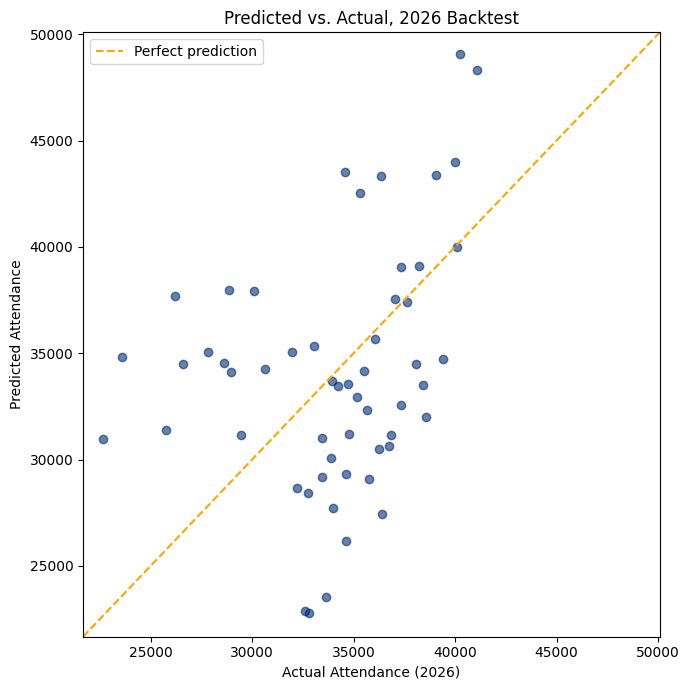

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, test_pred, alpha=0.6, color="#002D72")
lims = [min(y_test.min(), test_pred.min()) - 1000, max(y_test.max(), test_pred.max()) + 1000]
ax.plot(lims, lims, color="orange", linestyle="--", label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual Attendance (2026)")
ax.set_ylabel("Predicted Attendance")
ax.set_title("Predicted vs. Actual, 2026 Backtest")
ax.legend()
plt.tight_layout()
plt.show()

## Coefficients, What's Driving the Model
Each coefficient is the predicted change in attendance for a one-unit increase in that feature, holding everything else constant. Opponent dummies are collapsed into a single "opponent effect" summary (min/max/mean) since there are ~20 of them.

**Caveat before reading these:** this is the "Linear, all 4 seasons" model, the same one that scores worse than just guessing the historical average on the 2026 backtest (see the comparison table further down). With only 281 training rows and several correlated features (e.g. `mets_win_pct` and `opp_win_pct`), individual coefficients are unstable, not precise real-world effect sizes. We watched this directly earlier: `opp_win_pct`'s coefficient swung from -22,887 to -16,480 to -6,022 across small feature-set changes, same data, wildly different number each time. Also remember `mets_win_pct` is on a 0-1 scale, so its coefficient is the effect of going from a team that never wins to a team that never loses, the full theoretical range, not a realistic single-season swing. Read the **sign and rough ranking** as informative; don't quote the **exact magnitude** as a trustworthy dollar/ticket figure.

Intercept (baseline attendance, reference opponent): -3,928,556

Non-opponent feature coefficients, strongest first:
mets_win_pct           21045.6
opp_win_pct            -5467.1
is_weekend              3237.4
is_premium_national    -2368.7
n_promotions            2025.3
season                  1943.8
is_bobblehead           1609.6
is_day_game             1251.7
is_national              965.4
avg_precip_mm           -948.1
month                    766.4
mets_streak_num         -241.9
opp_starter_era          159.9
avg_temp_f               142.9
is_promo                 129.8
is_game2                -129.0
mets_games_back         -105.1
mets_starter_era          85.7
dayofweek                 61.6
dtype: float64

Opponent effect range: -3,310 to 14,475 (mean 2,191)
Top 5 opponent draws:
opponent_New York Yankees         14475.0
opponent_Los Angeles Dodgers       8004.0
opponent_Toronto Blue Jays         6974.0
opponent_Philadelphia Phillies     5989.0
opponent_Los Angeles Angels        

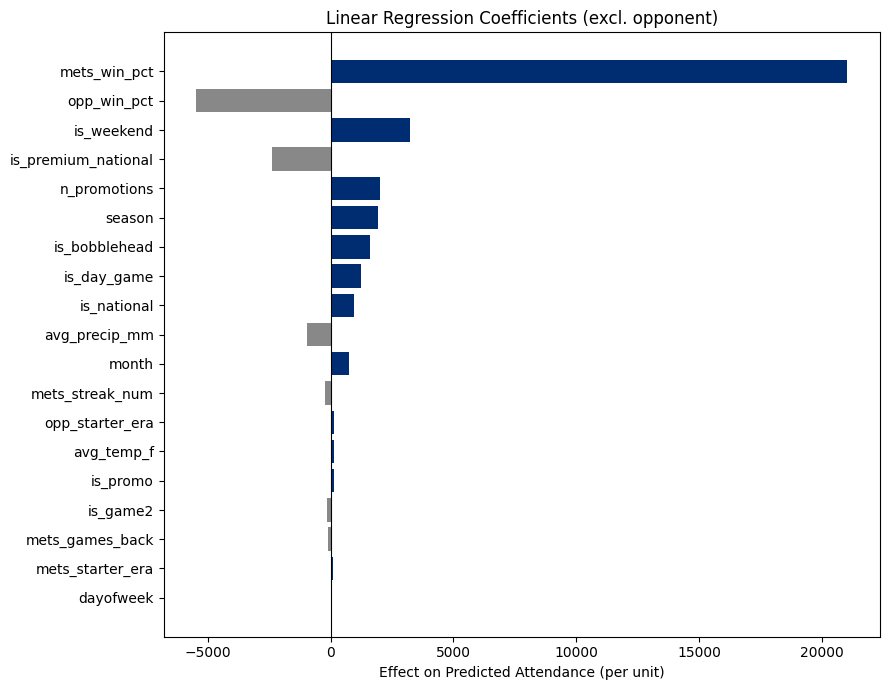

In [6]:
coefs = pd.Series(model.coef_, index=X_train.columns)
opp_coefs = coefs[coefs.index.str.startswith("opponent_")]
non_opp_coefs = coefs[~coefs.index.str.startswith("opponent_")].sort_values(key=abs, ascending=False)

print(f"Intercept (baseline attendance, reference opponent): {model.intercept_:,.0f}\n")
print("Non-opponent feature coefficients, strongest first:")
print(non_opp_coefs.round(1))
print(f"\nOpponent effect range: {opp_coefs.min():,.0f} to {opp_coefs.max():,.0f} (mean {opp_coefs.mean():,.0f})")
print("Top 5 opponent draws:")
print(opp_coefs.sort_values(ascending=False).head(5).round(0))
print("Bottom 5 opponent draws:")
print(opp_coefs.sort_values(ascending=False).tail(5).round(0))

plt.figure(figsize=(9, 7))
colors = ["#002D72" if v > 0 else "#888" for v in non_opp_coefs.values[::-1]]
plt.barh(non_opp_coefs.index[::-1], non_opp_coefs.values[::-1], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Effect on Predicted Attendance (per unit)")
plt.title("Linear Regression Coefficients (excl. opponent)")
plt.tight_layout()
plt.show()

## Per-Game Backtest Detail
Every completed 2026 game the model never trained on, actual vs. predicted.

In [7]:
backtest = test.loc[test_model.index, ["date", "opponent", "attendance"]].copy()
backtest["predicted"] = test_pred
backtest["error"] = backtest["predicted"] - backtest["attendance"]
backtest["abs_pct_error"] = (backtest["error"].abs() / backtest["attendance"] * 100).round(1)
backtest = backtest.sort_values("date")

print(f"Mean absolute % error: {backtest['abs_pct_error'].mean():.1f}%")
print(f"Median absolute % error: {backtest['abs_pct_error'].median():.1f}%")
backtest.round(0)

Mean absolute % error: 15.8%
Median absolute % error: 13.1%


,date,opponent,attendance,predicted,error,abs_pct_error
3,2026-04-07,Arizona Diamondbacks,34753.0,31192.0,-3561.0,10.0
4,2026-04-08,Arizona Diamondbacks,33422.0,31026.0,-2396.0,7.0
5,2026-04-09,Arizona Diamondbacks,35783.0,29106.0,-6677.0,19.0
7,2026-04-11,Athletics,38244.0,39103.0,859.0,2.0
8,2026-04-12,Athletics,37316.0,32558.0,-4758.0,13.0
9,2026-04-21,Minnesota Twins,32798.0,22777.0,-10021.0,31.0
12,2026-04-24,Colorado Rockies,36233.0,30500.0,-5733.0,16.0
14,2026-04-28,Washington Nationals,33622.0,23539.0,-10083.0,30.0
15,2026-04-29,Washington Nationals,32624.0,22866.0,-9758.0,30.0
16,2026-04-30,Washington Nationals,34621.0,26175.0,-8446.0,24.0


## Training Window Comparison
Team performance swings a lot year to year, so a smaller, more recent training window might track next season better than pooling everything. Compare all-4-seasons vs. 2024-2025 vs. 2025-only, all evaluated against the same 2026 backtest. (Spoiler: it did not)

(Reminder: negative R² = worse than the naive historical-mean guess, see the note above. These get worse the smaller the window, not better, that's the actual finding here.)

In [8]:
def fit_linear_window(seasons_included, label):
    mask = train_model["season"].isin(seasons_included)
    sub = train_encoded[mask]
    X_sub, y_sub = sub.drop(columns=[TARGET]), sub[TARGET]
    m = LinearRegression()
    m.fit(X_sub, y_sub)
    pred = m.predict(X_test)
    metrics = evaluate(y_test, pred)
    print(f"{label:<20} n={len(sub):>4}  R²={metrics['r2']:6.3f}  MAE={metrics['mae']:>8,.0f}  "
          f"RMSE={metrics['rmse']:>8,.0f}  MAPE={metrics['mape']:5.1f}%")
    return {"model": m, "pred": pred, **metrics}

window_results = {}
for seasons_included, label in [([2022, 2023, 2024, 2025], "All 4 seasons"),
                                 ([2024, 2025], "2024-2025 only"),
                                 ([2025], "2025 only")]:
    window_results[label] = fit_linear_window(seasons_included, label)

All 4 seasons        n= 281  R²=-0.976  MAE=   5,099  RMSE=   5,956  MAPE= 15.8%
2024-2025 only       n= 137  R²=-7.029  MAE=  10,581  RMSE=  12,005  MAPE= 33.0%
2025 only            n=  71  R²=-0.344  MAE=   3,916  RMSE=   4,911  MAPE= 12.1%


## Tree-Based Models
281 training rows with 46 features (mostly opponent dummies) is a small, wide dataset for tree ensembles, they can easily fit noise that doesn't generalize, especially to a new season with a real level shift like 2026. Trying them anyway since it's cheap to check, but the linear model remains the one we'd actually explain decisions with.

(Reminder: negative R² = worse than the naive historical-mean guess. GBM comes closest to breaking even here, RF doesn't.)

In [9]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

X_train_full = train_encoded.drop(columns=[TARGET])
y_train_full = train_encoded[TARGET]

tree_results = {}

rf = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42)
rf.fit(X_train_full, y_train_full)
rf_pred = rf.predict(X_test)
tree_results["Random Forest"] = {"model": rf, "pred": rf_pred, **evaluate(y_test, rf_pred)}

gbm = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gbm.fit(X_train_full, y_train_full)
gbm_pred = gbm.predict(X_test)
tree_results["Gradient Boosting"] = {"model": gbm, "pred": gbm_pred, **evaluate(y_test, gbm_pred)}

for label, r in tree_results.items():
    print(f"{label:<20} R²={r['r2']:6.3f}  MAE={r['mae']:>8,.0f}  RMSE={r['rmse']:>8,.0f}  MAPE={r['mape']:5.1f}%")

Random Forest        R²=-2.131  MAE=   6,056  RMSE=   7,497  MAPE= 19.9%
Gradient Boosting    R²=-0.921  MAE=   4,242  RMSE=   5,873  MAPE= 14.2%


## Ensemble & Full Comparison
Simple average of the linear (all 4 seasons), Random Forest, and Gradient Boosting predictions, not a trained meta-model (true stacking), just averaging to see if blending smooths out each model's individual bias. Then every approach side by side.

(Reminder: negative R² = worse than the naive historical-mean guess. Every approach here is still negative, the ensemble is the least-bad, not a winner.)

In [10]:
ensemble_pred = (window_results["All 4 seasons"]["pred"] + rf_pred + gbm_pred) / 3
ensemble_metrics = evaluate(y_test, ensemble_pred)

all_results = {**window_results, **tree_results, "Ensemble (avg of 3)": {"pred": ensemble_pred, **ensemble_metrics}}

summary = pd.DataFrame({
    label: {"R2": r["r2"], "MAE": r["mae"], "RMSE": r["rmse"], "MAPE": r["mape"]}
    for label, r in all_results.items()
}).T.sort_values("MAE")

print("All approaches, evaluated on the same 48-game 2026 backtest, sorted by MAE:")
summary.round(3)

All approaches, evaluated on the same 48-game 2026 backtest, sorted by MAE:


,R2,MAE,RMSE,MAPE
2025 only,-0.344,3915.532,4911.384,12.144
Ensemble (avg of 3),-0.763,4130.391,5626.247,13.737
Gradient Boosting,-0.921,4242.162,5872.995,14.161
All 4 seasons,-0.976,5099.113,5956.402,15.771
Random Forest,-2.131,6055.567,7496.766,19.889
2024-2025 only,-7.029,10581.273,12005.363,33.014


## Feature Importance Across All Three Model Types
Each model ranks "what matters" differently: linear regression by absolute coefficient size, Random Forest and Gradient Boosting by how much each feature actually reduces prediction error across splits. All three normalized to sum to 1 (relative importance, not tickets) so they're comparable side by side. All ~20 opponent dummies are collapsed into one `opponent (all teams)` row, otherwise they'd dominate the table without telling us much individually.

In [11]:
def grouped_importance(values, feature_names):
    s = pd.Series(values, index=feature_names)
    opp_mask = s.index.str.startswith("opponent_")
    grouped = s[~opp_mask].copy()
    grouped["opponent (all teams)"] = s[opp_mask].sum()
    return grouped / grouped.sum()

linear_model = window_results["All 4 seasons"]["model"]
linear_imp = grouped_importance(np.abs(linear_model.coef_), X_train_full.columns)
rf_imp = grouped_importance(rf.feature_importances_, X_train_full.columns)
gbm_imp = grouped_importance(gbm.feature_importances_, X_train_full.columns)

importance_table = pd.DataFrame({
    "Linear (|coef|, normalized)": linear_imp,
    "Random Forest": rf_imp,
    "Gradient Boosting": gbm_imp,
})
importance_table["avg_rank"] = importance_table.rank(ascending=False).mean(axis=1)
importance_table = importance_table.sort_values("avg_rank").drop(columns="avg_rank")

print("Relative importance by model (each column sums to 1.0), sorted by average rank across all three:")
importance_table.round(3)

Relative importance by model (each column sums to 1.0), sorted by average rank across all three:


,"Linear (|coef|, normalized)",Random Forest,Gradient Boosting
season,0.015,0.343,0.299
opponent (all teams),0.661,0.046,0.175
opp_win_pct,0.043,0.077,0.055
mets_win_pct,0.167,0.061,0.045
is_weekend,0.026,0.048,0.051
avg_temp_f,0.001,0.129,0.116
dayofweek,0.000,0.121,0.072
n_promotions,0.016,0.010,0.018
opp_starter_era,0.001,0.030,0.025
month,0.006,0.021,0.023


## Naive Baseline Comparisons
Standard R² compares a model to the test set's *own* mean, which quietly assumes you already know the answer. Four honest baselines instead, each using only information that would actually be available before 2026 started:
1. **Historical mean**, average attendance across all of 2022-2025
2. **Last year's average**, 2025's average attendance only (captures recent trend for free)
3. **Same matchup last year**, that specific opponent's average home-game attendance in 2025 (falls back to that opponent's all-time training average, then the overall historical mean, if they didn't visit in 2025)
4. **Same weekday/month average**, historical average attendance for that month + day-of-week combination

If a model can't beat these, it isn't adding real value over a five-minute spreadsheet lookup.

In [12]:
# 1. Historical mean (2022-2025), already computed at the top of the notebook
baseline_historical = pd.Series(historical_mean, index=test_model.index)

# 2. Last year's average (2025 only)
avg_2025 = train.loc[train["season"] == 2025, "attendance"].mean()
baseline_last_year = pd.Series(avg_2025, index=test_model.index)

# 3. Same matchup last year, that opponent's 2025 home-game average, falling back to
#    their all-time training average, then the overall historical mean
matchup_2025 = train.loc[train["season"] == 2025].groupby("opponent")["attendance"].mean()
matchup_alltime = train.groupby("opponent")["attendance"].mean()

def matchup_baseline(opponent):
    if opponent in matchup_2025.index:
        return matchup_2025[opponent]
    if opponent in matchup_alltime.index:
        return matchup_alltime[opponent]
    return historical_mean

baseline_matchup = test_model["opponent"].map(matchup_baseline)

# 4. Same weekday/month average
calendar_avg = train.groupby(["month", "dayofweek"])["attendance"].mean()

def calendar_baseline(row):
    key = (row["month"], row["dayofweek"])
    return calendar_avg.get(key, historical_mean)

baseline_calendar = test_model.apply(calendar_baseline, axis=1)

print(f"Historical mean (2022-2025):  {historical_mean:,.0f}")
print(f"Last year's average (2025):   {avg_2025:,.0f}")
print(f"Same matchup last year:       {baseline_matchup.min():,.0f} - {baseline_matchup.max():,.0f} (varies by opponent)")
print(f"Same weekday/month average:   {baseline_calendar.min():,.0f} - {baseline_calendar.max():,.0f} (varies by date)")

Historical mean (2022-2025):  33,876
Last year's average (2025):   39,776
Same matchup last year:       15,936 - 42,659 (varies by opponent)
Same weekday/month average:   25,688 - 39,238 (varies by date)


## Final Comparison: Every Model vs. Every Baseline
R² here is computed against the historical-mean baseline specifically (not the test set's own mean), so a positive value means genuinely earned skill over the simplest honest guess.

(Reminder: with the current full backtest, every model comes back negative here, the historical mean baseline itself is the best performer. See the note after the table for what that means and where we test a fix.)

In [13]:
all_predictions = {
    "Baseline: Historical Mean (2022-2025)": baseline_historical,
    "Baseline: Last Year's Avg (2025)": baseline_last_year,
    "Baseline: Same Matchup Last Year": baseline_matchup,
    "Baseline: Same Weekday/Month Avg": baseline_calendar,
    "Linear (all 4 seasons)": window_results["All 4 seasons"]["pred"],
    "Random Forest": rf_pred,
    "Gradient Boosting": gbm_pred,
    "Ensemble (avg of 3)": ensemble_pred,
}

final_table = pd.DataFrame({
    label: evaluate(y_test, pred)
    for label, pred in all_predictions.items()
}).T.sort_values("mae")
final_table.columns = ["R2_vs_historical_mean", "MAE", "RMSE", "MAPE"]

print("Every model and naive baseline, evaluated on the same 2026 backtest, sorted by MAE:")
final_table.round(3)

Every model and naive baseline, evaluated on the same 2026 backtest, sorted by MAE:


,R2_vs_historical_mean,MAE,RMSE,MAPE
Baseline: Historical Mean (2022-2025),0.000,3315.080,4236.879,10.433
Ensemble (avg of 3),-0.763,4130.391,5626.247,13.737
Gradient Boosting,-0.921,4242.162,5872.995,14.161
Baseline: Same Weekday/Month Avg,-0.775,4601.527,5644.247,14.584
Linear (all 4 seasons),-0.976,5099.113,5956.402,15.771
Baseline: Last Year's Avg (2025),-1.820,5802.628,7114.957,19.084
Random Forest,-2.131,6055.567,7496.766,19.889
Baseline: Same Matchup Last Year,-3.010,6865.875,8484.197,21.859


The original R² (comparing against the 2026 test set's own average) made these models look barely better than a coin flip, which was confusing given the MAPEs looked reasonable on their own. That comparison wasn't fair: the test set's own mean isn't something you'd actually know before 2026 happened, so it's not a real "dummy guess." Switching to the historical mean (33,876, the best of the four candidate baselines above) as the fixed reference point made the comparison honest, and the honest answer, with the full 69-game 2026 backtest now included, is that **none of these models beat it**. Gradient Boosting and the ensemble come closest, but the historical mean baseline itself is now the top performer (R²=0.000 by definition, MAE=3,315 vs. GBM's 4,242). Earlier in this notebook's history, with fewer 2026 games available, GBM and the ensemble did edge out the baseline, so this isn't a fixed verdict, it's shifted as more of the season came in, which is itself the finding: with this little training data and this much season-to-season volatility, "beats a naive average" is a fragile, moving target, not something to declare permanently won.

Next: implement this against the 2026 games so far and predict game by game as the season progresses.